In [1]:
from _action import Translation

In [2]:
from _css import ToricCode
from _channel import Depolarising
from _experiment import BatchGenerator

from _draw import *
from pauli import wedge_dense 

from _decoder import XZ_PymatchDecoder, BruteForceDecoder

import numpy as np
from tqdm import tqdm


import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def check_syndrome_g(noise_b, syndrome_b, g, code, **kwargs):
    g_syndrome = g.syndrome_action(syndrome_b, **kwargs)
    g_noise_b = g.chain_action(noise_b, **kwargs)
    syndrome_g = wedge_dense(g_noise_b, generator.to_dense(code.stabilizers()))
    assert np.allclose(syndrome_g, g_syndrome)

In [4]:
xkwargs, ykwargs = {}, {}
xkwargs['direction'] = 'x'
ykwargs['direction'] = 'y'

In [5]:
g = Translation(3)
coset_drawer = CosetProbsPrinting()

Check permutation of indexes:

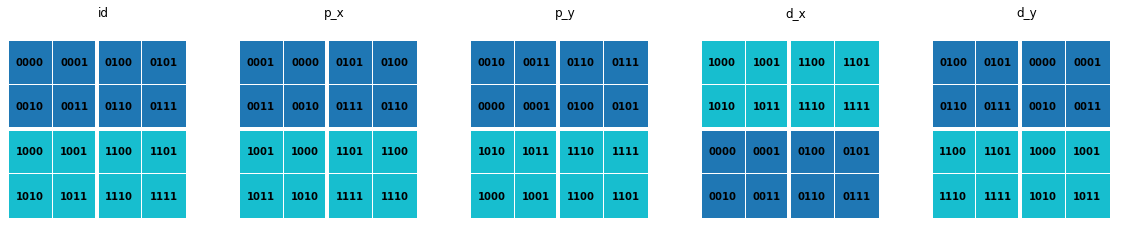

In [6]:
decoder = BruteForceDecoder(ToricCode(3), None)
coset_idx = np.array([np.array2string(decoder.coset_logic[i,:], separator='')[1:-1] for i in range(16)]).reshape(1,4,2,2)

primal_x = g.primal_non_id_logic_action(coset_idx, direction='x')  
primal_y = g.primal_non_id_logic_action(coset_idx, direction='y')  

dual_x = g.dual_non_id_logic_action(coset_idx, direction='x')
dual_y = g.dual_non_id_logic_action(coset_idx, direction='y')


fig, ax = plt.subplots(1,5, figsize=(20,10))
for a, title, coset in zip(ax.flatten(), ['id','p_x', 'p_y', 'd_x', 'd_y'], [coset_idx, primal_x, primal_y, dual_x, dual_y]):
    coset_drawer.draw_probs(coset[0], a, title)

Check syndrome translation:

In [9]:
for power in range(3):
    
    xkwargs['power'] = power
    ykwargs['power'] = power

    b_size = 512
    for L in tqdm([3,9,11,12]):
        for p in [0.15, 0.12, 0.9]:
            noise_model_z = Depolarising(2*L**2, (0, p ,0))
            noise_model_x = Depolarising(2*L**2, (p, 0 ,0))
            noise_model_y = Depolarising(2*L**2, (0, 0 ,p))
            noise_model_depolar = Depolarising(2*L**2, (p/3., p/3. ,p/3.))
            for noise_model in [noise_model_z, noise_model_x, noise_model_y, noise_model_depolar]:
                code = ToricCode(L)
                generator = BatchGenerator(code, noise_model)
                noise_b, syndrome_b, _ = generator.generate_batch(b_size)
                noise_b = generator.to_dense(noise_b)

                g_translation = Translation(L)

                check_syndrome_g(noise_b, syndrome_b, g_translation, code, **xkwargs)
                check_syndrome_g(noise_b, syndrome_b, g_translation, code, **ykwargs)

100%|█████████████████████████████████████████████| 4/4 [00:02<00:00,  1.43it/s]


Check condition of permutation:

Check permutation of logicals:

In [10]:
def check_logicals_g(syndrome, decoder, g, **kwargs): 
    g_syndrome = g.syndrome_action(syndrome, **kwargs)
    
    probs_syndrome = decoder.decode2probs(syndrome)
    probs_g_syndrome = decoder.decode2probs(g_syndrome)
    g_probs_syndrome = g.logic_action(probs_syndrome, syndrome, **kwargs)
    
    assert np.allclose(g_probs_syndrome, probs_g_syndrome, rtol=1e-7, atol=1e-9)

In [12]:
L = 3
code = ToricCode(L)
b_size = 1024

for power in range(3):
    
    xkwargs['power'] = power
    ykwargs['power'] = power

    xkwargs['direction'] = 'x'
    ykwargs['direction'] = 'y'
    g_translation = Translation(L)

    p = 0.15
    noise_model_z = Depolarising(2*L**2, (0, p ,0))
    noise_model_x = Depolarising(2*L**2, (p, 0 ,0))
    noise_model_y = Depolarising(2*L**2, (0, 0 ,p))
    noise_model_depolar = Depolarising(2*L**2, (p/2., p/3. ,p/5.))

    for noise_model, noise_type in tqdm(zip([noise_model_z, noise_model_x, noise_model_y, noise_model_depolar], ['z', 'x', 'y', 'zxy'])):
        decoder = BruteForceDecoder(code, noise_model.log_prob)
        generator = BatchGenerator(code, noise_model)
        noise_b, syndrome_b, _ = generator.generate_batch(b_size)

        check_logicals_g(syndrome_b, decoder, g_translation, **xkwargs)
        check_logicals_g(syndrome_b, decoder, g_translation, **ykwargs)
        print(noise_type + ' done')

1it [06:09, 369.64s/it]

z done


2it [12:27, 374.21s/it]

x done


3it [18:37, 372.60s/it]

...

x done


3it [18:28, 369.50s/it]

y done


4it [24:37, 369.49s/it]

zxy done
